# OMNI Solar Wind Parameters EDA

This notebook explores the `juliensimon/omni-solar-wind-parameters` datasetm for the geomagnetic storm prediction project.

The goal of this EDA is to determine whether this dataset can support out project question: predicting whether a geomagnetic storm will occur, or predicting storm intensity, using solar activity and solar wind features.

Compared with the initial real-time Solar Wind dataset, this OMNI dataset has a much longer time range and includes both solar wind/IMF variables and geomagnetic response indices in one hourly time series. Because it contains possible predictors and possible target variables together, this EDA will focus on separating input features from target candidates and checking data quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%pip install datasets -q
from datasets import load_dataset


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
ds = load_dataset("juliensimon/omni-solar-wind-parameters", split="train")
df = ds.to_pandas()

df.head()

README.md: 0.00B [00:00, ?B/s]

data/omni_solar_wind_parameters.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/561024 [00:00<?, ? examples/s]

,datetime,bartels_rotation_number,b_magnitude_avg_nt,b_magnitude_vector_nt,b_lat_angle_gse_deg,b_lon_angle_gse_deg,bx_gse_nt,by_gse_nt,bz_gse_nt,by_gsm_nt,...,proton_flux_gt4mev,proton_flux_gt10mev,proton_flux_gt30mev,proton_flux_gt60mev,ap_index_nt,f107_index_sfu,pc_n_index,al_index_nt,au_index_nt,magnetosonic_mach_number
0,1963-01-01 00:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
1,1963-01-01 01:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
2,1963-01-01 02:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
3,1963-01-01 03:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN
4,1963-01-01 04:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN


### Initial Head Observation

**Key takeaways**
- Early rows: many missing solar wind / IMF values
- Geomagnetic indices: available earlier than many predictor variables
- Missingness pattern: likely differs by variable group and time period

**EDA decision**
- Check coverage before choosing features
- Use observed rows only, not future placeholder rows
- Separate predictors vs target candidates early
- Watch for target leakage

In [5]:
df.shape

(561024, 48)

### Dataset Size

- Rows: 561,024 hourly records
- Columns: 48 variables
- This dataset is much larger and longer than the real-time solar wind dataset.
- Main EDA focus: variable coverage, target candidates, and usable feature groups.

In [6]:
column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values,
    "non_missing_count": df.notna().sum().values,
    "unique_count": df.nunique().values
})

column_summary

,column,dtype,missing_count,missing_percent,non_missing_count,unique_count
0,datetime,datetime64[us],0,0.00,561024,561024
1,bartels_rotation_number,float64,4920,0.88,556104,859
2,b_magnitude_avg_nt,float64,129103,23.01,431921,453
3,b_magnitude_vector_nt,float64,129103,23.01,431921,446
4,b_lat_angle_gse_deg,float64,129103,23.01,431921,1790
5,b_lon_angle_gse_deg,float64,129103,23.01,431921,3602
6,bx_gse_nt,float64,129103,23.01,431921,498
7,by_gse_nt,float64,129103,23.01,431921,607
8,bz_gse_nt,float64,129103,23.01,431921,588
9,by_gsm_nt,float64,129129,23.02,431895,591


In [7]:
measurement_cols = [col for col in df.columns if col != "datetime"]

df["has_any_measurement"] = df[measurement_cols].notna().any(axis=1)

df.loc[df["has_any_measurement"], "datetime"].min(), df.loc[df["has_any_measurement"], "datetime"].max()

(Timestamp('1963-01-01 00:00:00'), Timestamp('2026-06-10 11:00:00'))

In [8]:
df["has_any_measurement"].value_counts()

has_any_measurement
True     556116
False      4908
Name: count, dtype: int64

In [9]:
df_observed = df[df["has_any_measurement"]].copy()

df_observed.shape

(556116, 49)

### Future Placeholder Rows Check

**What we see**
- The full dataset has timestamps through 2026-12-31, but actual measurements are available through 2026-06-10 11:00:00.
- 4908 rows have `datetime` only and no other measurement values. 
- `df_observed` keeps only rows with at least one non-datetime measruement. 

**Decision**
- Use `df_observed` for missingness summaries, visualizations, and modeling feasibility checks.

In [10]:
observed_column_summary = pd.DataFrame({
    "column": df_observed.drop(columns=["has_any_measurement"]).columns,
    "dtype": df_observed.drop(columns=["has_any_measurement"]).dtypes.astype(str).values,
    "missing_count": df_observed.drop(columns=["has_any_measurement"]).isna().sum().values,
    "missing_percent": (df_observed.drop(columns=["has_any_measurement"]).isna().mean() * 100).round(2).values,
    "non_missing_count": df_observed.drop(columns=["has_any_measurement"]).notna().sum().values,
    "unique_count": df_observed.drop(columns=["has_any_measurement"]).nunique().values
})

observed_column_summary

,column,dtype,missing_count,missing_percent,non_missing_count,unique_count
0,datetime,datetime64[us],0,0.00,556116,556116
1,bartels_rotation_number,float64,12,0.00,556104,859
2,b_magnitude_avg_nt,float64,124195,22.33,431921,453
3,b_magnitude_vector_nt,float64,124195,22.33,431921,446
4,b_lat_angle_gse_deg,float64,124195,22.33,431921,1790
5,b_lon_angle_gse_deg,float64,124195,22.33,431921,3602
6,bx_gse_nt,float64,124195,22.33,431921,498
7,by_gse_nt,float64,124195,22.33,431921,607
8,bz_gse_nt,float64,124195,22.33,431921,588
9,by_gsm_nt,float64,124221,22.34,431895,591


### Observed Column Coverage

**Key takeaways**
- Target candidates: almost complete  
  - `dst_index_nt`, `kp_index`, `ap_index_nt`
- Key IMF variables: ~22% missing  
  - example: `bz_gsm_nt`
- Key solar wind variables: ~23–26% missing  
  - `flow_speed_kms`, `proton_density_cm3`, `flow_pressure_npa`
- Energetic proton flux variables: much higher missingness

**EDA decision**
- Use `df_observed` for EDA
- Do not use all observed rows automatically for modeling
- Build a smaller modeling dataset after choosing:
  - target variable
  - selected input features
  - acceptable missingness threshold

In [11]:
imf_cols = [
    "b_magnitude_avg_nt",
    "b_magnitude_vector_nt",
    "bx_gse_nt",
    "by_gse_nt",
    "bz_gse_nt",
    "by_gsm_nt",
    "bz_gsm_nt"
]

solar_wind_cols = [
    "proton_temperature_k",
    "proton_density_cm3",
    "flow_speed_kms",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "plasma_beta",
    "alfven_mach_number",
    "magnetosonic_mach_number"
]

target_candidate_cols = [
    "kp_index",
    "dst_index_nt",
    "ap_index_nt",
    "ae_index_nt",
    "al_index_nt",
    "au_index_nt"
]

solar_context_cols = [
    "sunspot_number",
    "f107_index_sfu"
]

particle_cols = [
    "proton_flux_gt1mev",
    "proton_flux_gt2mev",
    "proton_flux_gt4mev",
    "proton_flux_gt10mev",
    "proton_flux_gt30mev",
    "proton_flux_gt60mev"
]

In [12]:
groups = {
    "IMF / magnetic field": imf_cols,
    "Solar wind plasma / derived": solar_wind_cols,
    "Target candidates / geomagnetic indices": target_candidate_cols,
    "Solar context": solar_context_cols,
    "Energetic particles": particle_cols
}

group_summary = []

for group_name, cols in groups.items():
    group_missing = df_observed[cols].isna().mean().mean() * 100
    group_complete_rows = df_observed[cols].notna().all(axis=1).mean() * 100
    
    group_summary.append({
        "group": group_name,
        "num_columns": len(cols),
        "avg_missing_percent": round(group_missing, 2),
        "complete_rows_percent": round(group_complete_rows, 2)
    })

pd.DataFrame(group_summary)

,group,num_columns,avg_missing_percent,complete_rows_percent
0,IMF / magnetic field,7,22.33,77.66
1,Solar wind plasma / derived,8,28.04,68.12
2,Target candidates / geomagnetic indices,6,4.32,89.78
3,Solar context,2,0.07,99.87
4,Energetic particles,6,48.35,35.47


### Variable Group Coverage

**Key takeaways**
- Best coverage: solar context variables
- Mostly complete: target candidates / geomagnetic indices
- Usable coverage:
  - IMF / magnetic field: 77.66% complete rows
  - Solar wind plasma / derived: 68.12% complete rows
- Lower priority for first model:
  - Energetic particle variables
  - Reason: high missingness

**EDA decision**
- Prioritize IMF, solar wind, and target candidate variables
- Treat energetic particle variables as optional for later analysis
- Build final modeling dataset after choosing:
  - target variable
  - selected input features
  - missingness threshold

**Note**
- Derived variables are calculated from measured solar wind / IMF variables.
- They may be useful domain features, but can overlap with raw variables.

## Priority Column Dictionary

| Column | Group | Plain-English meaning | Modeling role |
|---|---|---|---|
| `datetime` | Time | Hourly timestamp for each observation | Needed for time-based analysis and merging |
| `bz_gsm_nt` | IMF / magnetic field | North-south magnetic field component in GSM coordinates; negative means southward Bz | Key input candidate |
| `by_gsm_nt` | IMF / magnetic field | East-west magnetic field component in GSM coordinates | Input candidate |
| `b_magnitude_avg_nt` | IMF / magnetic field | Average total interplanetary magnetic field strength during the hour | Input candidate |
| `flow_speed_kms` | Solar wind plasma | Solar wind speed in km/s | Key input candidate |
| `proton_density_cm3` | Solar wind plasma | Solar wind proton density | Input candidate |
| `proton_temperature_k` | Solar wind plasma | Solar wind proton temperature | Input candidate |
| `flow_pressure_npa` | Derived solar wind | Solar wind dynamic pressure | Input candidate |
| `electric_field_mvpm` | Derived solar wind | Interplanetary electric field related to solar wind speed and Bz | Strong input candidate; check leakage/derivation |
| `plasma_beta` | Derived solar wind | Ratio of plasma pressure to magnetic pressure | Optional input candidate |
| `kp_index` | Geomagnetic index | Planetary geomagnetic activity index; stored as Kp × 10 | Target candidate |
| `dst_index_nt` | Geomagnetic index | Storm-time disturbance index; more negative values indicate stronger storms | Target candidate |
| `ap_index_nt` | Geomagnetic index | Linear version of Kp-style geomagnetic activity | Target candidate |
| `ae_index_nt` | Geomagnetic index | Auroral electrojet activity index | Secondary target/context candidate |
| `sunspot_number` | Solar context | Proxy for solar cycle activity | Context feature candidate |
| `f107_index_sfu` | Solar context | Solar 10.7 cm radio flux; proxy for solar activity/EUV output | Context feature candidate |

## Time Range and Cadence Check

This dataset is expected to be hourly. We check the observed time range and the gaps between consecutive timestamps.

In [17]:
df_observed = df_observed.sort_values("datetime").copy()
df_observed["time_diff"] = df_observed["datetime"].diff()
df_observed["datetime"].min(), df_observed["datetime"].max()

(Timestamp('1963-01-01 00:00:00'), Timestamp('2026-06-10 11:00:00'))

In [18]:
df_observed["time_diff"].value_counts().head(10)

time_diff
0 days 01:00:00    556115
Name: count, dtype: int64

### Time Range and Cadence Observation

**Key takeaways**
- Observed range: 1963-01-01 00:00:00 → 2026-06-10 11:00:00
- Cadence: exactly 1 hour between consecutive rows
- Irregular gaps: none found in `df_observed`

**EDA decision**
- Dataset is ready for hourly time-series analysis
- No time-gap handling needed at this stage

## Target Candidate Exploration

We first create a binary geomagnetic storm label using `kp_index`.

Since `kp_index` is stored as Kp × 10, `kp_index >= 50` represents Kp 5.0 or higher, a common threshold for geomagnetic storm conditions.

In [23]:
kp_valid = df_observed[df_observed["kp_index"].notna()].copy()

kp_valid["kp_storm"] = kp_valid["kp_index"] >= 50

kp_valid["kp_storm"].value_counts()

kp_storm
False    533028
True      23076
Name: count, dtype: int64

### Kp Storm Label Balance (related to storm occurence)

**What we see**
- Rows with missing `kp_index` were excluded before creating the storm label.
- Non-storm hours: 533,028
- Storm hours: 23,076
- Kp-based storm hours make up about 4.15% of valid Kp rows.

**Why it matters**
- Storm hours are rare compared with non-storm hours.
- This makes the project an imbalanced classification problem.
- Later modeling should not rely on accuracy alone.

In [25]:
round(kp_valid["kp_storm"].mean() * 100, 2)

np.float64(4.15)

### Dst-Based Storm Candidate (related to storm intensity / strength)

`dst_index_nt` measures geomagnetic disturbance. More negative values indicate stronger geomagnetic storm conditions.

We test a simple Dst-based storm label using `dst_index_nt <= -50`.

In [26]:
dst_valid = df_observed[df_observed["dst_index_nt"].notna()].copy()

dst_valid["dst_storm"] = dst_valid["dst_index_nt"] <= -50

dst_valid["dst_storm"].value_counts()

dst_storm
False    525308
True      30808
Name: count, dtype: int64

In [27]:
round(dst_valid["dst_storm"].mean() * 100, 2)

np.float64(5.54)

### Dst Storm Label Balance

**What we see**
- Rows with missing `dst_index_nt` were excluded before creating the Dst storm label.
- Non-storm hours: 525,308
- Storm hours: 30,808
- Dst-based storm hours make up about 5.54% of valid Dst rows.

**Why it matters**
- Dst-based storm hours are still rare, but slightly more common than Kp-based storm hours.
- `dst_index_nt` may be useful for storm intensity analysis because more negative values represent stronger disturbance.

In [28]:
target_compare = pd.DataFrame({
    "target_definition": ["Kp storm: kp_index >= 50", "Dst storm: dst_index_nt <= -50"],
    "storm_hours": [kp_valid["kp_storm"].sum(), dst_valid["dst_storm"].sum()],
    "total_valid_rows": [len(kp_valid), len(dst_valid)],
    "storm_percent": [
        round(kp_valid["kp_storm"].mean() * 100, 2),
        round(dst_valid["dst_storm"].mean() * 100, 2)
    ]
})

target_compare

,target_definition,storm_hours,total_valid_rows,storm_percent
0,Kp storm: kp_index >= 50,23076,556104,4.15
1,Dst storm: dst_index_nt <= -50,30808,556116,5.54


### Target Candidate Comparison

**Key takeaways**
- Kp storm label: `kp_index >= 50`
  - Storm hours: 23,076
  - Storm rate: 4.15%
- Dst storm label: `dst_index_nt <= -50`
  - Storm hours: 30,808
  - Storm rate: 5.54%
- Both labels are highly imbalanced

**EDA decision**
- Use Kp label for clear storm / non-storm classification
- Keep Dst label as an alternative for storm intensity analysis
- Do not choose final target yet
- Final target depends on project focus:
  - storm occurrence
  - storm intensity
  - both

In [29]:
selected_input_cols = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa",
    "electric_field_mvpm"
]

kp_feature_compare = kp_valid.groupby("kp_storm")[selected_input_cols].median().T

kp_feature_compare.columns = ["non_storm_median", "storm_median"]

kp_feature_compare

,non_storm_median,storm_median
bz_gsm_nt,0.00,-3.60
b_magnitude_avg_nt,5.40,10.90
flow_speed_kms,408.00,551.00
proton_density_cm3,5.10,7.00
flow_pressure_npa,1.76,4.19
electric_field_mvpm,-0.00,2.03


### Input Feature Comparison by Kp Storm Label

**Storm pattern**
- Bz: more negative / southward
- Magnetic field: stronger
- Solar wind: faster
- Density / pressure: higher
- Electric field: higher

**EDA takeaway**
- Selected IMF and solar wind variables show clear differences between storm and non-storm hours.
- These variables are reasonable input candidates for the first storm classification model.

<Figure size 600x400 with 0 Axes>

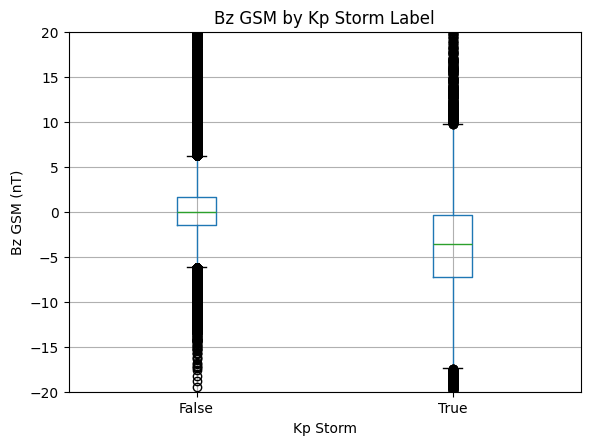

In [31]:
plt.figure(figsize=(6, 4))

kp_valid.boxplot(column="bz_gsm_nt", by="kp_storm")

plt.title("Bz GSM by Kp Storm Label")
plt.suptitle("")
plt.xlabel("Kp Storm")
plt.ylabel("Bz GSM (nT)")
plt.ylim(-20, 20)

plt.show()

### Bz GSM by Kp Storm Label

**Key takeaways**
- Storm hours: lower median `bz_gsm_nt`
- Pattern: Bz is more negative / southward during storm hours
- Full plot: many outliers
- Final plot choice: limited y-axis for readability

**EDA takeaway**
- Southward Bz is a key storm-related signal
- `bz_gsm_nt` is a strong input candidate for the first model

## Correlation Check for Priority Variables

We check correlations among selected input variables and target candidates. This is not meant to prove causation, but it helps identify which variables may contain useful predictive signal.

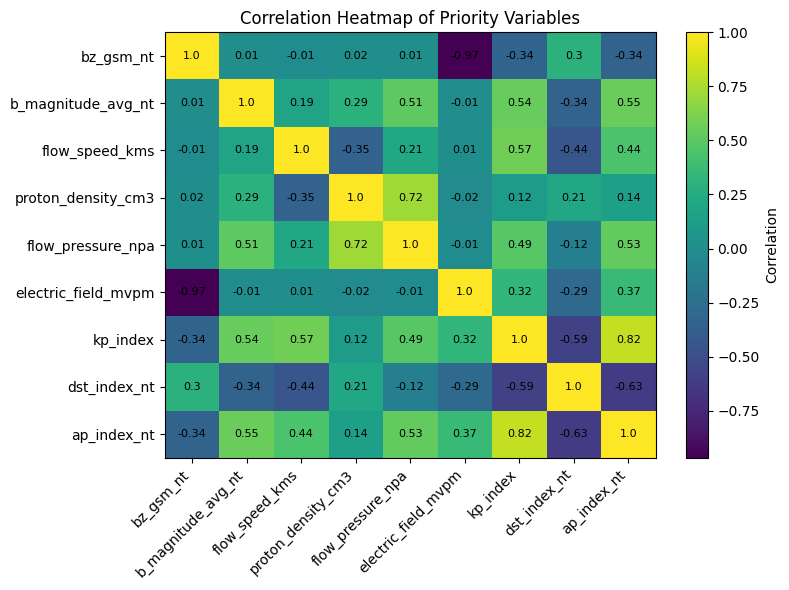

In [34]:
corr_cols = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "kp_index",
    "dst_index_nt",
    "ap_index_nt"
]

corr_matrix = df_observed[corr_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap of Priority Variables")

plt.tight_layout()
plt.show()

### Correlation Heatmap Observation

**Key takeaways**
- `kp_index`: positive relationship with  
  - `flow_speed_kms`
  - `b_magnitude_avg_nt`
  - `flow_pressure_npa`
  - `electric_field_mvpm`
- `dst_index_nt`: negative relationship with  
  - `flow_speed_kms`
  - `b_magnitude_avg_nt`
  - `electric_field_mvpm`
- Dst interpretation:
  - lower Dst = stronger storm disturbance
  - negative correlation can still mean stronger storm signal
- `kp_index` and `ap_index_nt`: highly correlated
- `bz_gsm_nt` and `electric_field_mvpm`: strongly overlapping signal

**EDA takeaway**
- Priority solar wind / IMF variables show storm-related signal
- Do not use geomagnetic indices as inputs if one of them is the target
- Derived variables may help, but can overlap with raw variables

## Summary Statistics for Priority Input Variables

We check basic summary statistics for selected input variables to understand their ranges and possible extreme values.

In [35]:
selected_input_cols = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa",
    "electric_field_mvpm"
]

df_observed[selected_input_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bz_gsm_nt,431895.0,-0.019617,3.151968,-57.80,-1.60,0.0,1.50,58.90
b_magnitude_avg_nt,431921.0,6.181991,3.181405,0.40,4.20,5.5,7.30,68.90
flow_speed_kms,427717.0,434.178034,102.063856,156.00,358.00,411.0,490.00,1189.00
proton_density_cm3,411396.0,6.644431,5.395433,0.00,3.30,5.1,8.20,137.20
flow_pressure_npa,411388.0,2.238252,1.872459,0.00,1.22,1.8,2.67,76.06
electric_field_mvpm,403972.0,0.012465,1.464983,-63.26,-0.64,-0.0,0.67,47.11


### Summary Statistics Observation

**Key takeaways**
- Most priority variables: normal median values, but extreme min/max values
- Centered near 0:
  - `bz_gsm_nt`
  - `electric_field_mvpm`
- High-end spikes:
  - `flow_speed_kms`
  - `proton_density_cm3`
  - `flow_pressure_npa`

**EDA takeaway**
- Extreme values may be real storm-related signals
- Do not automatically remove outliers
- Inspect extreme values before deciding outlier handling for modeling

In [36]:
outlier_summary = []

for col in selected_input_cols:
    series = df_observed[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_percent = outlier_count / len(series) * 100
    
    outlier_summary.append({
        "column": col,
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_percent, 2),
        "min": round(series.min(), 2),
        "max": round(series.max(), 2)
    })

pd.DataFrame(outlier_summary)

,column,lower_bound,upper_bound,outlier_count,outlier_percent,min,max
0,bz_gsm_nt,-6.25,6.15,22354,5.18,-57.80,58.90
1,b_magnitude_avg_nt,-0.45,11.95,21337,4.94,0.40,68.90
2,flow_speed_kms,160.00,688.00,8920,2.09,156.00,1189.00
3,proton_density_cm3,-4.05,15.55,24212,5.89,0.00,137.20
4,flow_pressure_npa,-0.95,4.84,23813,5.79,0.00,76.06
5,electric_field_mvpm,-2.60,2.64,23047,5.71,-63.26,47.11


### Outlier Summary Observation

**Key takeaways**
- IQR outliers found in all priority input variables
- Most outlier rates: about 2–6%
- Extreme values appear in:
  - `bz_gsm_nt`
  - `flow_speed_kms`
  - `proton_density_cm3`
  - `flow_pressure_npa`
  - `electric_field_mvpm`

**EDA takeaway**
- Outliers may be real storm-related events
- Do not remove outliers during initial EDA
- Decide outlier handling later based on modeling goal

## Final EDA Summary

**Main findings**
- The OMNI dataset provides a long hourly time series from 1963-01-01 to 2026-06-10 for observed measurements.
- The dataset includes both potential predictor variables and geomagnetic target candidates.
- Future placeholder rows were removed before the main EDA.
- Target candidates such as `kp_index`, `dst_index_nt`, and `ap_index_nt` have strong coverage.
- Key IMF and solar wind variables have some missingness but remain usable for a first modeling pass.
- Energetic particle variables have much higher missingness and may be lower priority for the initial model.

**Target candidate findings**
- `kp_index >= 50` creates a Kp-based storm label with about 4.15% storm hours.
- `dst_index_nt <= -50` creates a Dst-based storm label with about 5.54% storm hours.
- Both target definitions show that geomagnetic storm prediction is an imbalanced classification problem.

**Feature signal findings**
- Storm hours have more negative `bz_gsm_nt`, stronger magnetic field values, faster solar wind speed, higher proton density, higher dynamic pressure, and higher electric field values.
- Correlation patterns suggest that selected IMF and solar wind variables contain useful signal for storm prediction.
- Derived variables such as `electric_field_mvpm` may be useful but may overlap with raw variables like `bz_gsm_nt` and `flow_speed_kms`.

**Modeling implications**
- A first model could use `kp_index >= 50` as a binary storm classification target.
- Candidate input features include `bz_gsm_nt`, `b_magnitude_avg_nt`, `flow_speed_kms`, `proton_density_cm3`, `flow_pressure_npa`, and `electric_field_mvpm`.
- Geomagnetic indices should not be used as input features when one of them is the target.
- Evaluation should include recall, precision, and F1-score instead of accuracy alone because storm hours are rare.